# LSTM (8-bar log-return) — log-return features

Same net and label as **lstm_baseline_v1**, with the main design smell fixed.

- **Input:** last 200 SPY 5-minute bars of **in-window log returns** `(batch, 200, 5)`: `log(O/C_prev)`, `log(H/C_prev)`, `log(L/C_prev)`, `log(C/C_prev)`, `log(V/V_prev)`
- **Target:** still one-shot `log(C_{t+8} / C_t)`
- **Net:** `LSTM(32) → Dense(16, ReLU) → Dense(1)`, Adam, MSE on scaled y
- **Split:** chrono 70/15/15 plus an embargo of `window + horizon` samples so train/val/test windows do not share bars
- **Signal:** skip unless `|expected_move_pct| > 0.10%` (was 0, which over-traded)
- **Exits:** unchanged (±0.30% TP/SL, 8-bar timeout, flatten at 15:55 ET)

Weights go to `models/lstm/` so the raw-OHLCV baseline in `models/lstm/` is not overwritten.

In [1]:
# Start .venv in terminal
# ----------------------
# .\.venv\Scripts\activate
# python -m ipykernel install --user --name=.venv --display-name "Python (.venv)"
# ----------------------

In [1]:
import json
import os
import random
import sys
from pathlib import Path

_ROOT = Path.cwd() if (Path.cwd() / "Data_Handling.py").exists() else Path.cwd().parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Dense, Input, LSTM
from tensorflow.keras.models import Sequential

from Data_Handling import fetch_alpaca_vbt_data

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# -----------------------
# Config (matches live template defaults)
# -----------------------
SYMBOL = "SPY"
START = "2024-07-01"
END = "2026-05-01"
TIMEFRAME_UNIT = "Minute"
MULTIPLIER = 5

WINDOW = 200
HORIZON = 2
EPOCHS = 25
BATCH_SIZE = 64
PATIENCE = 20

MIN_EXPECTED_MOVE_PCT = 0.000  # skip if |pred| <= 0.10%
DIRECTION = "both"  # long_only | short_only | both
TARGET_PCT = 0.002  # +0.30% TP
STOP_PCT = 0.002    # -0.30% SL
FLATTEN_AFTER_ET = "15:55"  # last regular 5m bar

FEATURES = "log_returns"
EMBARGO = WINDOW + HORIZON

MODEL_DIR = _ROOT / "models" / "lstm"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "model.h5"
SCALER_PATH = MODEL_DIR / "scaler.json"
TARGET_SCALER_PATH = MODEL_DIR / "target_scaler.json"

In [3]:
df = fetch_alpaca_vbt_data(
    symbol=SYMBOL,
    start=START,
    end=END,
    timeframe_unit=TIMEFRAME_UNIT,
    multiplier=MULTIPLIER,
)
ohlcv = df[["Open", "High", "Low", "Close", "Volume"]].to_numpy(dtype=np.float64)
closes = ohlcv[:, 3]
print(df.tail())
print(f"bars={len(df):,}  {df.index.min()} → {df.index.max()}")

field                          Open      High     Low    Close   Volume
timestamp                                                              
2026-04-30 23:35:00+00:00  720.1400  720.2500  720.13  720.130   5681.0
2026-04-30 23:40:00+00:00  720.1410  720.1500  720.01  720.010   6311.0
2026-04-30 23:45:00+00:00  719.9600  720.1300  719.96  720.051   2490.0
2026-04-30 23:50:00+00:00  720.0999  720.1932  719.89  719.890   3484.0
2026-04-30 23:55:00+00:00  719.9300  719.9700  719.60  719.870  13457.0
bars=87,119  2024-07-01 08:00:00+00:00 → 2026-04-30 23:55:00+00:00


## Windows and labels

Features are **bar-to-bar log returns** on the full tape, then sliced into 200-bar windows. Label is still `y = log(C_j / C_t)` with `t = i + window - 1`, `j = t + horizon`.

Split is chronological 70/15/15 with an **embargo** of `window + horizon` samples between folds so overlapping windows do not leak prices into val/test.

In [4]:
if "ohlcv" not in globals():
    df = fetch_alpaca_vbt_data(
        symbol=SYMBOL,
        start=START,
        end=END,
        timeframe_unit=TIMEFRAME_UNIT,
        multiplier=MULTIPLIER,
    )
    ohlcv = df[["Open", "High", "Low", "Close", "Volume"]].to_numpy(dtype=np.float64)
    closes = ohlcv[:, 3]
    print(f"bars={len(df):,}  {df.index.min()} → {df.index.max()}")


def ohlcv_to_log_features(ohlcv: np.ndarray) -> np.ndarray:
    o, h, l, c, v = (ohlcv[:, i] for i in range(5))
    c_prev = np.empty_like(c)
    c_prev[0] = c[0]
    c_prev[1:] = c[:-1]
    v_prev = np.empty_like(v)
    v_prev[0] = np.maximum(v[0], 1.0)
    v_prev[1:] = np.maximum(v[:-1], 1.0)
    c_prev = np.maximum(c_prev, 1e-12)
    v = np.maximum(v, 1.0)
    return np.stack(
        [
            np.log(o / c_prev),
            np.log(h / c_prev),
            np.log(l / c_prev),
            np.log(c / c_prev),
            np.log(v / v_prev),
        ],
        axis=1,
    )


def make_windows_returns_hstep(ohlcv: np.ndarray, window: int = 200, horizon: int = 8):
    close = ohlcv[:, 3]
    feats = ohlcv_to_log_features(ohlcv)
    n = len(ohlcv)
    n_win = n - window - horizon + 1
    Xs = np.lib.stride_tricks.sliding_window_view(feats, window, axis=0)[:n_win]
    # sliding_window_view appends the window axis: (n_win, 5, window) -> (n_win, window, 5)
    Xs = np.ascontiguousarray(np.transpose(Xs, (0, 2, 1)))
    t_idx = np.arange(window - 1, window - 1 + n_win)
    c_t = close[t_idx]
    c_j = close[t_idx + horizon]
    valid = np.isfinite(c_t) & np.isfinite(c_j) & (c_t > 0) & (c_j > 0)
    y = np.log(c_j / c_t)
    return Xs[valid], y[valid], t_idx[valid]


def chrono_split_embargo(n: int, train_frac: float = 0.70, val_frac: float = 0.15, embargo: int = 0):
    i70 = int(train_frac * n)
    i85 = int((train_frac + val_frac) * n)
    return slice(0, i70), slice(i70 + embargo, i85), slice(i85 + embargo, n)


X_all, y_all, t_all = make_windows_returns_hstep(ohlcv, WINDOW, HORIZON)
assert X_all.shape[1:] == (WINDOW, 5), X_all.shape
print(f"X_all shape: {X_all.shape}  y_all shape: {y_all.shape}  features={FEATURES}")

train_sl, val_sl, test_sl = chrono_split_embargo(len(X_all), embargo=EMBARGO)
X_train, y_train, t_train = X_all[train_sl], y_all[train_sl], t_all[train_sl]
X_val, y_val, t_val = X_all[val_sl], y_all[val_sl], t_all[val_sl]
X_test, y_test, t_test = X_all[test_sl], y_all[test_sl], t_all[test_sl]
print(f"split: {len(X_train)} / {len(X_val)} / {len(X_test)} train/val/test  embargo={EMBARGO}")

X_all shape: (86918, 200, 5)  y_all shape: (86918,)  features=log_returns
split: 60842 / 12836 / 12836 train/val/test  embargo=202


## Scalers

Feature `StandardScaler` is still fit on **training windows only** (flattened over time). Inputs are already log returns, so the scaler only equalizes OHLC vs volume magnitude.
Target scaler is unchanged: z-score of training 8-bar log-returns.

In [5]:
feature_scaler = StandardScaler()
feature_scaler.fit(X_train.reshape(-1, 5))

target_scaler = StandardScaler()
y_train_s = target_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_s = target_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_s = target_scaler.transform(y_test.reshape(-1, 1)).ravel()


def scale_windows(X: np.ndarray) -> np.ndarray:
    return feature_scaler.transform(X.reshape(-1, 5)).reshape(X.shape)


X_train_s = scale_windows(X_train)
X_val_s = scale_windows(X_val)
X_test_s = scale_windows(X_test)


def invert_log_return(y_scaled: np.ndarray) -> np.ndarray:
    y_scaled = np.asarray(y_scaled).reshape(-1)
    return y_scaled * target_scaler.scale_[0] + target_scaler.mean_[0]


print("feature mean:", np.round(feature_scaler.mean_, 4))
print("target mean/scale:", float(target_scaler.mean_[0]), float(target_scaler.scale_[0]))

feature mean: [ 0.      0.0004 -0.0004  0.      0.    ]
target mean/scale: 6.632474865010145e-06 0.001164560207553003


In [6]:
model = Sequential(
    [
        Input(shape=(WINDOW, 5)),
        LSTM(32, return_sequences=False),
        Dense(16, activation="relu"),
        Dense(1),
    ]
)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,409 (21.13 KB)

 Trainable params: 5,409 (21.13 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
    ),
    ModelCheckpoint(
        filepath=str(MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
    ),
]

history = model.fit(
    X_train_s,
    y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=False,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/25


951/951 - 53s - 56ms/step - loss: 1.0027 - mae: 0.5096 - val_loss: 0.5244 - val_mae: 0.4251
Epoch 2/25
951/951 - 51s - 54ms/step - loss: 0.9988 - mae: 0.5087 - val_loss: 0.5249 - val_mae: 0.4250
Epoch 3/25
951/951 - 51s - 54ms/step - loss: 0.9963 - mae: 0.5084 - val_loss: 0.5244 - val_mae: 0.4250
Epoch 4/25
951/951 - 48s - 51ms/step - loss: 0.9936 - mae: 0.5082 - val_loss: 0.5245 - val_mae: 0.4252
Epoch 5/25
951/951 - 72s - 75ms/step - loss: 0.9905 - mae: 0.5084 - val_loss: 0.5257 - val_mae: 0.4255
Epoch 6/25
951/951 - 122s - 128ms/step - loss: 0.9861 - mae: 0.5079 - val_loss: 0.5257 - val_mae: 0.4255
Epoch 7/25
951/951 - 126s - 132ms/step - loss: 0.9798 - mae: 0.5076 - val_loss: 0.5256 - val_mae: 0.4256
Epoch 8/25
951/951 - 127s - 133ms/step - loss: 0.9732 - mae: 0.5073 - val_loss: 0.5252 - val_mae: 0.4254
Epoch 9/25
951/951 - 75s - 79ms/step - loss: 0.9674 - mae: 0.5071 - val_loss: 0.5249 - val_mae: 0.4253
Epoch 10/25
951/951 - 45s - 47ms/step - loss: 0.9655 - mae: 0.5069 - val_loss:

## Test metrics (price space)

`log_return = y_hat * target_scale + target_mean`  
`expected_move_pct = exp(log_return) - 1`  
`pred_close = C_t * exp(pred_log_return)`

Price-level MAPE on SPY can look excellent while 8-bar **direction** is still noise.

In [8]:
def evaluate_split(name: str, X_s: np.ndarray, y_true_log: np.ndarray, t_idx: np.ndarray):
    y_hat_s = model.predict(X_s, verbose=0).ravel()
    pred_log = invert_log_return(y_hat_s)
    c_t = closes[t_idx]
    c_true = c_t * np.exp(y_true_log)
    c_pred = c_t * np.exp(pred_log)
    move_pct = np.exp(pred_log) - 1.0

    rmse = float(np.sqrt(mean_squared_error(c_true, c_pred)))
    mae = float(mean_absolute_error(c_true, c_pred))
    mape = float(mean_absolute_percentage_error(c_true, c_pred))
    dir_acc = float(np.mean(np.sign(pred_log) == np.sign(y_true_log)))
    print(
        f"{name}: RMSE={rmse:.4f}  MAE={mae:.4f}  MAPE={mape:.4%}  "
        f"dir_acc={dir_acc:.3f}  mean_pred_log={pred_log.mean():.6f}"
    )
    return {
        "pred_log": pred_log,
        "true_log": y_true_log,
        "c_t": c_t,
        "c_true": c_true,
        "c_pred": c_pred,
        "move_pct": move_pct,
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "dir_acc": dir_acc,
    }


train_eval = evaluate_split("train", X_train_s, y_train, t_train)
val_eval = evaluate_split("val  ", X_val_s, y_val, t_val)
test_eval = evaluate_split("test ", X_test_s, y_test, t_test)

train: RMSE=0.6457  MAE=0.3410  MAPE=0.0592%  dir_acc=0.509  mean_pred_log=0.000025
val  : RMSE=0.5693  MAE=0.3352  MAPE=0.0495%  dir_acc=0.506  mean_pred_log=0.000021
test : RMSE=0.7717  MAE=0.4401  MAPE=0.0650%  dir_acc=0.505  mean_pred_log=0.000025


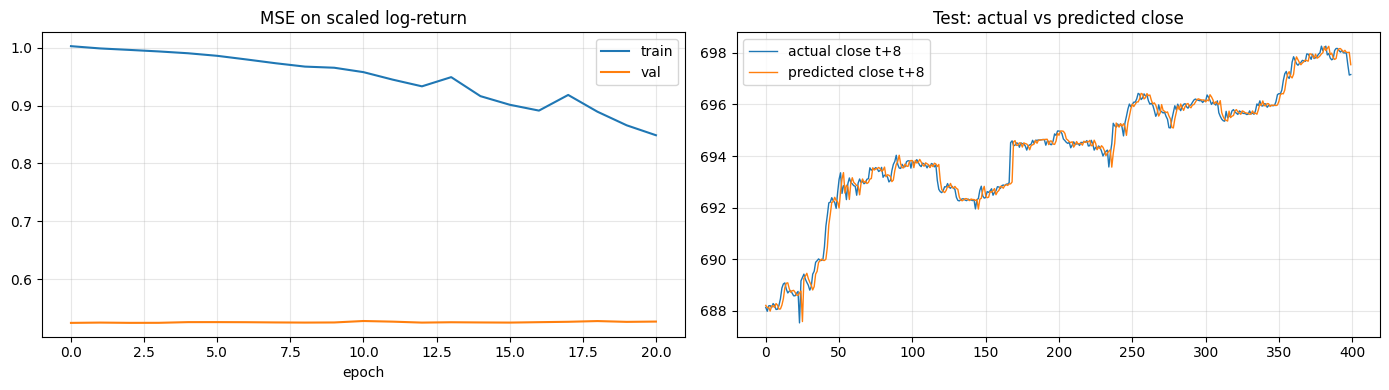

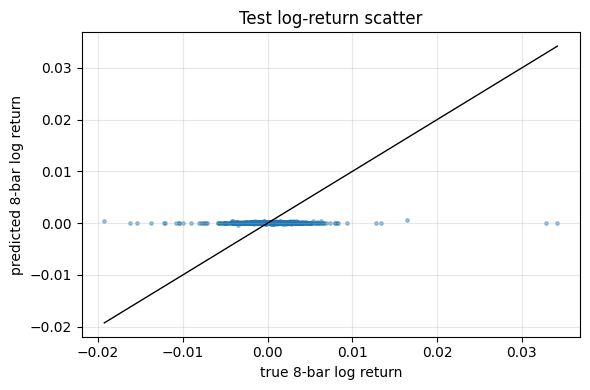

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("MSE on scaled log-return")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

n_plot = min(400, len(test_eval["c_true"]))
axes[1].plot(test_eval["c_true"][:n_plot], label="actual close t+8", linewidth=1)
axes[1].plot(test_eval["c_pred"][:n_plot], label="predicted close t+8", linewidth=1)
axes[1].set_title("Test: actual vs predicted close")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(test_eval["true_log"], test_eval["pred_log"], s=6, alpha=0.4)
lims = [
    min(test_eval["true_log"].min(), test_eval["pred_log"].min()),
    max(test_eval["true_log"].max(), test_eval["pred_log"].max()),
]
plt.plot(lims, lims, color="black", linewidth=1)
plt.xlabel("true 8-bar log return")
plt.ylabel("predicted 8-bar log return")
plt.title("Test log-return scatter")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Signals and triple-barrier backtest (test tail only)

While flat, each new candle: scale last 200 bars → one forward pass → invert scaler → `expected_move_pct`.

- `expected_move_pct > min_expected_move_pct` → long (if `both` / `long_only`)
- `expected_move_pct < -min_expected_move_pct` → short (if `both` / `short_only`)
- else skip

Default `min_expected_move_pct = 0` trades almost every non-zero prediction. One position at a time; no stacked entries. TP/SL are **not** taken from the network.

In [18]:
def signal_from_move(expected_move_pct: float, min_move: float = 0.0, direction: str = "both") -> int:
    if expected_move_pct > min_move and direction in ("long_only", "both"):
        return 1
    if expected_move_pct < -min_move and direction in ("short_only", "both"):
        return -1
    return 0


def is_flatten_bar(ts) -> bool:
    et = pd.Timestamp(ts)
    if et.tzinfo is None:
        et = et.tz_localize("UTC")
    et = et.tz_convert("America/New_York")
    hhmm = et.strftime("%H:%M")
    return hhmm >= FLATTEN_AFTER_ET


pred_by_t = {int(t): float(m) for t, m in zip(t_test, test_eval["move_pct"])}

start_i = int(t_test.min())
end_i = int(t_test.max())

in_pos = False
side = 0
entry_price = 0.0
entry_i = 0
expected_at_entry = 0.0
trades = []
equity = 1.0
curve = []

for i in range(start_i, end_i + 1):
    high, low, close = ohlcv[i, 1], ohlcv[i, 2], ohlcv[i, 3]
    ts = df.index[i]

    if in_pos:
        if side == 1:
            tp, sl = entry_price * (1 + TARGET_PCT), entry_price * (1 - STOP_PCT)
            hit_sl, hit_tp = low <= sl, high >= tp
        else:
            tp, sl = entry_price * (1 - TARGET_PCT), entry_price * (1 + STOP_PCT)
            hit_sl, hit_tp = high >= sl, low <= tp

        exit_price = None
        reason = None
        if hit_sl and hit_tp:
            exit_price, reason = sl, "ambiguous_sl"
        elif hit_sl:
            exit_price, reason = sl, "sl"
        elif hit_tp:
            exit_price, reason = tp, "tp"
        elif (i - entry_i) >= HORIZON:
            exit_price, reason = close, "timeout"
        elif is_flatten_bar(ts):
            exit_price, reason = close, "flatten_close"

        if exit_price is not None:
            ret = side * (exit_price / entry_price - 1.0)
            equity *= 1.0 + ret
            trades.append(
                {
                    "entry_time": df.index[entry_i],
                    "exit_time": ts,
                    "side": "long" if side == 1 else "short",
                    "entry": entry_price,
                    "exit": exit_price,
                    "ret": ret,
                    "reason": reason,
                    "expected_move_pct": expected_at_entry,
                    "bars_held": i - entry_i,
                }
            )
            in_pos = False
            side = 0
        curve.append((ts, equity))
        continue

    move = pred_by_t.get(i)
    if move is None:
        curve.append((ts, equity))
        continue

    sig = signal_from_move(move, MIN_EXPECTED_MOVE_PCT, DIRECTION)
    if sig != 0 and not is_flatten_bar(ts):
        in_pos = True
        side = sig
        entry_price = close
        entry_i = i
        expected_at_entry = move

    curve.append((ts, equity))

trades_df = pd.DataFrame(trades)
print(f"trades={len(trades_df)}  final_equity={equity:.4f}")
if len(trades_df):
    print(trades_df["reason"].value_counts().to_string())
    print(f"win_rate={(trades_df['ret'] > 0).mean():.3f}  mean_ret={trades_df['ret'].mean():.5f}")
    print(f"longs={(trades_df['side']=='long').sum()}  shorts={(trades_df['side']=='short').sum()}")
    display(trades_df.head())

trades=3262  final_equity=0.9807
reason
timeout          2811
sl                224
tp                204
flatten_close      16
ambiguous_sl        7
win_rate=0.498  mean_ret=-0.00001
longs=2869  shorts=393


,entry_time,exit_time,side,entry,exit,ret,reason,expected_move_pct,bars_held
0,2026-01-26 10:55:00+00:00,2026-01-26 11:05:00+00:00,short,688.21,688.13,0.000116,timeout,-0.000002,2
1,2026-01-26 11:10:00+00:00,2026-01-26 11:20:00+00:00,long,687.98,688.20,0.000320,timeout,0.000011,2
2,2026-01-26 11:25:00+00:00,2026-01-26 11:35:00+00:00,long,688.12,688.21,0.000131,timeout,0.000006,2
3,2026-01-26 11:40:00+00:00,2026-01-26 11:50:00+00:00,long,688.05,688.21,0.000233,timeout,0.000019,2
4,2026-01-26 11:55:00+00:00,2026-01-26 12:05:00+00:00,short,688.47,689.04,-0.000828,timeout,-0.000003,2


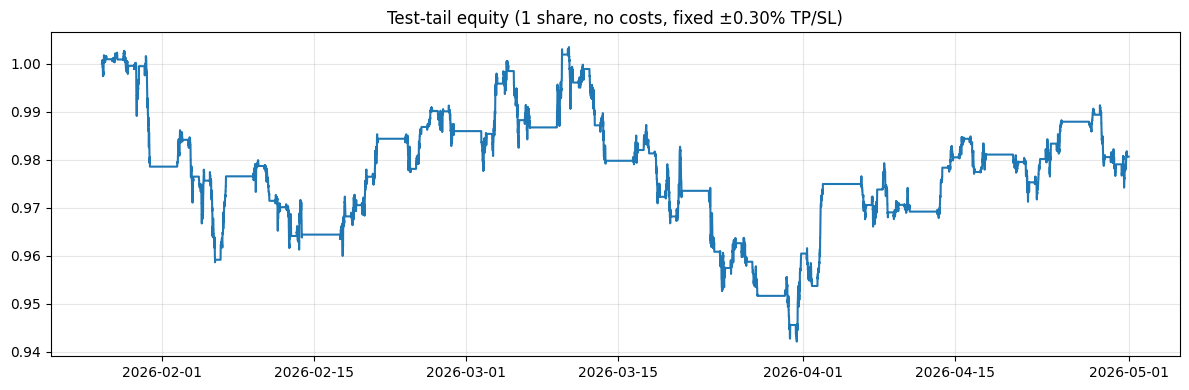

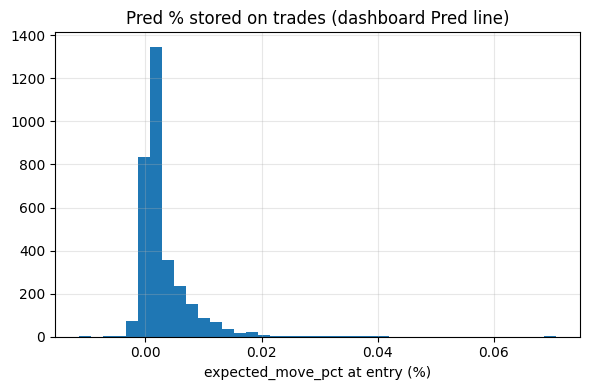

In [19]:
if curve:
    eq = pd.Series({t: e for t, e in curve})
    plt.figure(figsize=(12, 4))
    plt.plot(eq.index, eq.values)
    plt.title("Test-tail equity (1 share, no costs, fixed ±0.30% TP/SL)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if len(trades_df):
    plt.figure(figsize=(6, 4))
    plt.hist(trades_df["expected_move_pct"] * 100, bins=40)
    plt.xlabel("expected_move_pct at entry (%)")
    plt.title("Pred % stored on trades (dashboard Pred line)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [16]:
def dump_scaler(scaler: StandardScaler, path: Path):
    payload = {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
        "var": scaler.var_.tolist(),
        "n_features_in": int(scaler.n_features_in_),
    }
    path.write_text(json.dumps(payload, indent=2))


model.save(MODEL_PATH)
dump_scaler(feature_scaler, SCALER_PATH)
dump_scaler(target_scaler, TARGET_SCALER_PATH)
print(f"saved {MODEL_PATH}")
print(f"saved {SCALER_PATH}")
print(f"saved {TARGET_SCALER_PATH}")

saved c:\Mario\Projects\MoneyTalk\Trading ML\Trading-for-Dummies-test-\models\lstm_logret\model.h5
saved c:\Mario\Projects\MoneyTalk\Trading ML\Trading-for-Dummies-test-\models\lstm_logret\scaler.json
saved c:\Mario\Projects\MoneyTalk\Trading ML\Trading-for-Dummies-test-\models\lstm_logret\target_scaler.json
